# Gradient Boosted Survival Model
**In this notebook, we'll train and test a gradient boosting survival model from scikit-learn to predict 6 month survival from time of first line treatment for advanced head and neck cancer.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc

import matplotlib.pyplot as plt

from utils.cv_predictions import cross_validated_survival_predictions

## Import

In [2]:
dtype_map = pd.read_csv('../outputs/1L_features_training_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
train_df = pd.read_csv('../outputs/1L_features_training.csv', dtype = dtype_map)
train_df.shape

(6974, 154)

In [3]:
dtype_map = pd.read_csv('../outputs/1L_features_testing_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
test_df = pd.read_csv('../outputs/1L_features_testing.csv', dtype = dtype_map)
test_df.shape

(1744, 154)

In [4]:
censored_before_6m = (len(train_df.query('event == 0 and duration < 180', engine = 'python'))/len(train_df))*100
censored_before_12m = (len(train_df.query('event == 0 and duration < 365', engine = 'python'))/len(train_df))*100

print(f'Percentage censored before 6 months: {round(censored_before_6m, 1)}%')
print(f'Percentage censored before 12 months: {round(censored_before_12m, 1)}%')

Percentage censored before 6 months: 6.9%
Percentage censored before 12 months: 13.0%


## Preprocess

### Selecting features

#### Categorical variables

In [5]:
list(train_df.select_dtypes(include = ['category']).columns)

['AdvancedDiagnosisCriteria',
 'PrimarySite',
 'HPVTested',
 'HPVStatus_mod',
 'adv_diagnosis_year',
 'Ethnicity_mod',
 'Race_mod',
 'region',
 'PDL1_status',
 'PDL1_cps']

In [6]:
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns:
    value_props = train_df[var].value_counts(normalize=True)
    # Combine 'unknown' and 'Unknown' if both exist
    unknown_pct = value_props.get('unknown', 0) + value_props.get('Unknown', 0) + value_props.get('Unknown/Not documented', 0)
    var_dict[var] = round(unknown_pct*100, 3)

var_dict

{'AdvancedDiagnosisCriteria': 0,
 'PrimarySite': 0,
 'HPVTested': 0,
 'HPVStatus_mod': np.float64(34.012),
 'adv_diagnosis_year': 0,
 'Ethnicity_mod': 0,
 'Race_mod': 0,
 'region': np.float64(28.664),
 'PDL1_status': np.float64(92.114),
 'PDL1_cps': 0}

In [7]:
categorical_var = [
    'AdvancedDiagnosisCriteria',
    'PrimarySite',
    'HPVStatus_mod'
]

#### Binary variables 

In [8]:
list(train_df.select_dtypes(include = ['int']).columns)

['SmokingStatus',
 'received_surgery',
 'received_radiation',
 'had_local_recurrence',
 'had_distant_recurrence',
 'days_adv_to_treatment',
 'GroupStage_mod_na',
 'age',
 'sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'fevers',
 'hypoxemia',
 'anticoagulant',
 'opioid',
 'steroid',
 'antibiotic',
 'diabetic_med',
 'antidepressant',
 'bone_therapy_agent',
 'immunosuppressant',
 'chf',
 'cardiac_arrhythmias',
 'valvular_disease',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'htn_complicated',
 'paralysis',
 'other_neuro',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'pud',
 'aids_hiv',
 'lymphoma',
 'rheumatic',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'alcohol_abuse',
 'drug_abuse',
 'psychoses',
 'depression',
 'van_walraven_score',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met'

In [9]:
# Did not include days_adv_to_treatment, age, van_walraven, or event
bin_list = [
     'SmokingStatus',
     'received_surgery',
     'received_radiation',
     'had_local_recurrence',
     'had_distant_recurrence',
     'GroupStage_mod_na',
     'sex_male',
     'ecog_newly_gte2',
     'ecog_index_na',
     'hypotension',
     'tachycardia',
     'fevers',
     'hypoxemia',
     'anticoagulant',
     'opioid',
     'steroid',
     'antibiotic',
     'diabetic_med',
     'antidepressant',
     'bone_therapy_agent',
     'immunosuppressant',
     'chf',
     'cardiac_arrhythmias',
     'valvular_disease',
     'pulm_circulation',
     'pvd',
     'htn_uncomplicated',
     'htn_complicated',
     'paralysis',
     'other_neuro',
     'chronic_pulm_disease',
     'diabetes_uncomplicated',
     'diabetes_complicated',
     'hypothyroid',
     'renal_failure',
     'liver_disease',
     'pud',
     'aids_hiv',
     'lymphoma',
     'rheumatic',
     'coagulopathy',
     'obesity',
     'weight_loss',
     'fluid',
     'blood_loss_anemia',
     'deficiency_anemia',
     'alcohol_abuse',
     'drug_abuse',
     'psychoses',
     'depression',
     'lymph_met',
     'thoracic_met',
     'liver_met',
     'bone_met',
     'brain_met',
     'other_gi_met',
     'other_met'
]

In [10]:
# Identify binary variables with >3% prevalence 
bin_var_list = []
for bin_var in bin_list:
    if (train_df[bin_var].value_counts(normalize = True)[1] >= 0.03):
        bin_var_list.append(bin_var)

In [11]:
bin_var_list

['SmokingStatus',
 'received_surgery',
 'received_radiation',
 'had_local_recurrence',
 'had_distant_recurrence',
 'GroupStage_mod_na',
 'sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'hypoxemia',
 'opioid',
 'steroid',
 'antibiotic',
 'cardiac_arrhythmias',
 'pvd',
 'htn_uncomplicated',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'coagulopathy',
 'weight_loss',
 'fluid',
 'deficiency_anemia',
 'alcohol_abuse',
 'depression',
 'lymph_met',
 'thoracic_met',
 'bone_met',
 'other_met']

In [12]:
# GroupStage_mod_na and ecog_index_na added as flags later
binary_var = [
    'SmokingStatus',
    'received_surgery',
    'received_radiation',
    'had_local_recurrence',
    'had_distant_recurrence',
    'sex_male',
    'ecog_newly_gte2',
    'hypotension',
    'tachycardia',
    'hypoxemia',
    'opioid',
    'steroid',
    'antibiotic',
    'cardiac_arrhythmias',
    'pvd',
    'htn_uncomplicated',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'coagulopathy',
    'weight_loss',
    'fluid',
    'deficiency_anemia',
    'alcohol_abuse',
    'depression',
    'lymph_met',
    'thoracic_met',
    'bone_met',
    'other_met'
]

#### Numerical variables

In [13]:
list(train_df.select_dtypes(include = ['float64']).columns)

['GroupStage_mod',
 'days_diagnosis_to_adv',
 'ecog_index',
 'weight_index',
 'bmi_index',
 'percent_change_weight',
 'albumin',
 'alp',
 'alt',
 'ast',
 'bicarbonate',
 'bun',
 'calcium',
 'chloride',
 'creatinine',
 'hemoglobin',
 'platelet',
 'potassium',
 'sodium',
 'total_bilirubin',
 'wbc',
 'albumin_max',
 'alp_max',
 'alt_max',
 'ast_max',
 'bicarbonate_max',
 'bun_max',
 'calcium_max',
 'chloride_max',
 'creatinine_max',
 'hemoglobin_max',
 'platelet_max',
 'potassium_max',
 'sodium_max',
 'total_bilirubin_max',
 'wbc_max',
 'albumin_min',
 'alp_min',
 'alt_min',
 'ast_min',
 'bicarbonate_min',
 'bun_min',
 'calcium_min',
 'chloride_min',
 'creatinine_min',
 'hemoglobin_min',
 'platelet_min',
 'potassium_min',
 'sodium_min',
 'total_bilirubin_min',
 'wbc_min',
 'albumin_std',
 'alp_std',
 'alt_std',
 'ast_std',
 'bicarbonate_std',
 'bun_std',
 'calcium_std',
 'chloride_std',
 'creatinine_std',
 'hemoglobin_std',
 'platelet_std',
 'potassium_std',
 'sodium_std',
 'total_bilirub

In [14]:
# Added age, van_walraven_score, and days_adv_to_treatment here 
numerical_var = [
    'GroupStage_mod',
    'days_diagnosis_to_adv',
    'ecog_index',
    'weight_index',
    'bmi_index',
    'percent_change_weight',
    'albumin',
    'alp',
    'alt',
    'ast',
    'bicarbonate',
    'bun',
    'calcium',
    'chloride',
    'creatinine',
    'hemoglobin',
    'platelet',
    'potassium',
    'sodium',
    'total_bilirubin',
    'wbc',
    'alp_max',
    'alt_max',
    'ast_max',
    'calcium_max',
    'creatinine_max',
    'platelet_max',
    'potassium_max',
    'sodium_max',
    'total_bilirubin_max',
    'wbc_max',
    'albumin_min',
    'bicarbonate_min',
    'calcium_min',
    'hemoglobin_min',
    'platelet_min',
    'potassium_min',
    'sodium_min',
    'wbc_min',
    'age', 
    'van_walraven_score',
    'days_adv_to_treatment'
]

In [15]:
all_var = categorical_var + binary_var + numerical_var

In [16]:
missing = train_df[all_var].isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score       3030
albumin                  1341
chloride                 1285
albumin_min              1229
total_bilirubin          1210
alt                      1196
ast                      1174
alp                      1156
calcium                  1110
total_bilirubin_max      1095
bicarbonate              1089
alt_max                  1083
sodium                   1068
potassium                1066
ast_max                  1059
alp_max                  1042
calcium_max              1002
calcium_min              1002
bun                      1000
creatinine                989
bicarbonate_min           985
potassium_min             962
potassium_max             962
sodium_min                961
sodium_max                961
creatinine_max            889
percent_change_weight     526
platelet                  492
wbc                       492
hemoglobin                483
wbc_max                   452
wbc_min                   452
platelet_max              450
platelet_m

In [17]:
# Create a missing flag
for x in missing[missing > 0].index:
    train_df[f'{x}_na'] = np.where(train_df[x].isna(), 1, 0)
    test_df[f'{x}_na'] = np.where(test_df[x].isna(), 1, 0)

In [18]:
# Add missing flags to binary_var (this includes ecog_index_na and GroupStage_mod_na)
binary_var = binary_var + [col for col in train_df.columns if col.endswith('_na')]

In [19]:
all_var = categorical_var + binary_var + numerical_var

In [20]:
len(all_var)

115

### Setting up Y

In [21]:
y_dtype = [('event', bool), ('duration', float)]

In [22]:
# Death status and time until event needs to be stored as a structured array to be compatible with scikit-survival
train_y = np.array([tuple(x) for x in train_df[['event', 'duration']].values], 
                   dtype = y_dtype)

test_y = np.array([tuple(x) for x in test_df[['event', 'duration']].values], 
                  dtype = y_dtype)

### Creating pipeline

In [23]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_var),
        ("cat", categorical_pipeline, categorical_var),
        ("pass", "passthrough", binary_var),
    ],
    remainder="drop"
)

## Train model

In [24]:
def six_month_auc_scorer_approximate(estimator, X, y):
    """
    Approximate 180d AUC using test set for censoring estimation.
    This is not ideal but may be acceptable if censoring is light (eg., <20%).
    """
    chf_funcs = estimator.predict_cumulative_hazard_function(X)
    risk_scores = np.array([chf(180) for chf in chf_funcs])
    
    # Use same y for both (not ideal, but functional)
    auc, _ = cumulative_dynamic_auc(y, y, risk_scores, 180)
    return auc[0]

auc_scorer = make_scorer(
    six_month_auc_scorer_approximate,
    greater_is_better = True,
    needs_proba = False  
)

param_distributions = {
    'model__n_estimators': [300, 500],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.75, 0.85],
    'model__max_features': [0.7, 0.9]
}

gb = GradientBoostingSurvivalAnalysis(random_state = 42)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb)
])

search = RandomizedSearchCV(
    estimator = full_pipeline, 
    param_distributions = param_distributions, 
    n_iter = 20, 
    cv = 3,
    scoring = six_month_auc_scorer_approximate,
    refit = False,
    n_jobs = -1,
    random_state = 42,
    verbose = 1
)

search.fit(train_df[all_var], train_y)

print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__subsample': 0.75, 'model__n_estimators': 500, 'model__max_features': 0.9, 'model__max_depth': 2, 'model__learning_rate': 0.05}


In [25]:
results_df = pd.DataFrame(search.cv_results_)
results_df.sort_values('rank_test_score', ascending = True).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__n_estimators,param_model__max_features,param_model__max_depth,param_model__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,124.419443,0.710072,0.074213,0.003865,0.75,500,0.9,2,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.783722,0.732634,0.732099,0.749485,0.024210,1
11,131.917630,0.428382,0.075592,0.000117,0.85,500,0.7,2,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.783741,0.729698,0.732038,0.748492,0.024943,2
19,76.042466,1.206818,0.061052,0.000638,0.85,300,0.7,3,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.781086,0.732931,0.731383,0.748467,0.023074,3
8,74.913298,0.442624,0.070577,0.004634,0.75,300,0.9,2,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.783872,0.729345,0.730418,0.747878,0.025455,4
10,75.218855,0.272842,0.073688,0.002379,0.75,300,0.7,3,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.783391,0.730202,0.730027,0.747873,0.025115,5
4,74.106620,0.613978,0.068275,0.002595,0.75,300,0.7,2,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.781580,0.728757,0.733227,0.747854,0.023917,6
0,132.159904,0.531479,0.074994,0.000796,0.85,500,0.7,2,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.778342,0.731371,0.733268,0.747660,0.021709,7
18,126.793817,0.464244,0.063880,0.001894,0.85,500,0.9,3,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.779873,0.734207,0.728516,0.747532,0.022986,8
9,78.874158,0.275392,0.072487,0.004227,0.85,300,0.7,2,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.781258,0.729098,0.732196,0.747517,0.023892,9
17,83.009963,0.704649,0.076633,0.005259,0.85,300,0.9,4,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.771036,0.733666,0.737242,0.747315,0.016837,10


## Test model 

### Build final model 

In [26]:
best_gb_model = GradientBoostingSurvivalAnalysis(
    n_estimators = 500,  
    learning_rate = 0.05,
    max_depth = 2,
    subsample = 0.75,
    max_features = 0.9,
    verbose = 1,
    random_state = 42
)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_gb_model)
])

full_pipeline_final.fit(train_df[all_var], train_y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1       28755.6666           3.0980            4.17m
         2       28668.6076         -59.3074            4.13m
         3       28748.8707          83.3608            4.11m
         4       28552.3021        -155.5690            4.13m
         5       28539.5425          -3.3271            4.13m
         6       28679.6807         140.3523            4.13m
         7       28419.4132        -219.1097            4.13m
         8       28404.1915           1.0655            4.14m
         9       28443.9140          37.2659            4.14m
        10       28574.4794         124.1681            4.14m
        20       28521.6688          43.7531            4.07m
        30       28346.8095         -27.8527            3.98m
        40       28233.2495        -119.0825            3.89m
        50       28226.6483         -35.5740            3.80m
        60       28399.2181        -115.4802            3.71m
       

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['GroupStage_mod',
                                                   'days_diagnosis_to_adv',
                                                   'ecog_index', 'weight_index',
                                                   'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium', 'chloride',
                                                   'creatinine', 'hemoglobin',
                                                   'platelet', 'pot...
                                                   'diabetes_uncomplicated',
                                                   'hypothyroid',
                                                   'renal_failure',
                                                   'liver_disease',
                                                   'coagulopathy',
                                                   'weight_loss', 'fluid',
                                                   'deficiency_anemia',
                                                   'alcohol_abuse',
                                                   'depression', 'lymph_met',
                                                   'thoracic_met', 'bone_met', ...])])),
                ('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_depth=2, max_features=0.9,
                                                  n_estimators=500,
                                                  random_state=42,
                                                  subsample=0.75, verbose=1))])

### Evaluate performance on test and training set 

In [27]:
final_risk_scores_test = full_pipeline_final.predict(test_df[all_var])
final_auc_test = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, 180)[0][0]

print(f"Final 180-d AUC on Test Set: {final_auc_test:.3f}")

Final 180-d AUC on Test Set: 0.752


In [28]:
# Bootstrap 1000 180d AUCs for test set 
n_bootstraps = 1000
bootstrapped_scores_test = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_test), len(final_risk_scores_test))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        test_y[indices],
        final_risk_scores_test[indices],
        180
    )[0][0]
    bootstrapped_scores_test.append(auc_yr)

# Convert to array
bootstrapped_scores_test = np.array(bootstrapped_scores_test)

# Calculate 95% CI
conf_lower_test = np.percentile(bootstrapped_scores_test, 2.5)
conf_upper_test = np.percentile(bootstrapped_scores_test, 97.5)

In [29]:
final_risk_scores_train = full_pipeline_final.predict(train_df[all_var])
final_auc_train = cumulative_dynamic_auc(train_y, train_y, final_risk_scores_train, 180)[0][0]

print(f"Final 180-d AUC on Train Set: {final_auc_train:.3f}")

Final 180-d AUC on Train Set: 0.787


In [30]:
# Bootstrap 1000 180d AUCs for train set 
n_bootstraps = 1000
bootstrapped_scores_train = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_train), len(final_risk_scores_train))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        train_y[indices],
        final_risk_scores_train[indices],
        180
    )[0][0]
    bootstrapped_scores_train.append(auc_yr)

# Convert to array
bootstrapped_scores_train = np.array(bootstrapped_scores_train)

# Calculate 95% CI
conf_lower_train = np.percentile(bootstrapped_scores_train, 2.5)
conf_upper_train = np.percentile(bootstrapped_scores_train, 97.5)

In [31]:
gbm_auc_180d_data = {'model': ['gbm'],
                    'auc_180d_test': final_auc_test,
                    'auc_180d_test_lower': conf_lower_test,
                    'auc_180d_test_upper': conf_upper_test,
                    'auc_180d_train': final_auc_train,
                    'auc_180d_train_lower': conf_lower_train,
                    'auc_180d_train_upper': conf_upper_train}
 
gbm_auc_180d_df = pd.DataFrame(gbm_auc_180d_data)

In [32]:
gbm_auc_180d_df

,model,auc_180d_test,auc_180d_test_lower,auc_180d_test_upper,auc_180d_train,auc_180d_train_lower,auc_180d_train_upper
0,gbm,0.751758,0.725402,0.778225,0.787344,0.774355,0.800503


In [33]:
gbm_auc_180d_df.to_csv('../outputs/gbm_auc_180d_df.csv', index = False, header = True)

In [34]:
# Define evaluation times
times = np.arange(30, 1810, 30)

# Calculate AUCs across times
gbm_auc_over5 = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, times)[0]

# Build a dictionary mapping 'time_x' -> AUC at that time
times_data = {f"time_{int(t)}": auc for t, auc in zip(times, gbm_auc_over5)}

# Create DataFrame
gbm_auc_over5_df = pd.DataFrame(times_data, index=['gbm'])

In [35]:
gbm_auc_over5_df

,time_30,time_60,time_90,time_120,time_150,time_180,time_210,time_240,time_270,time_300,...,time_1530,time_1560,time_1590,time_1620,time_1650,time_1680,time_1710,time_1740,time_1770,time_1800
gbm,0.765178,0.788188,0.780919,0.780413,0.770104,0.751758,0.742837,0.744664,0.737991,0.73229,...,0.737823,0.746773,0.745308,0.735881,0.732722,0.732059,0.748245,0.750296,0.748575,0.744856


In [36]:
gbm_auc_over5_df.to_csv('../outputs/gbm_auc_over5_df.csv', index = True, header = True)

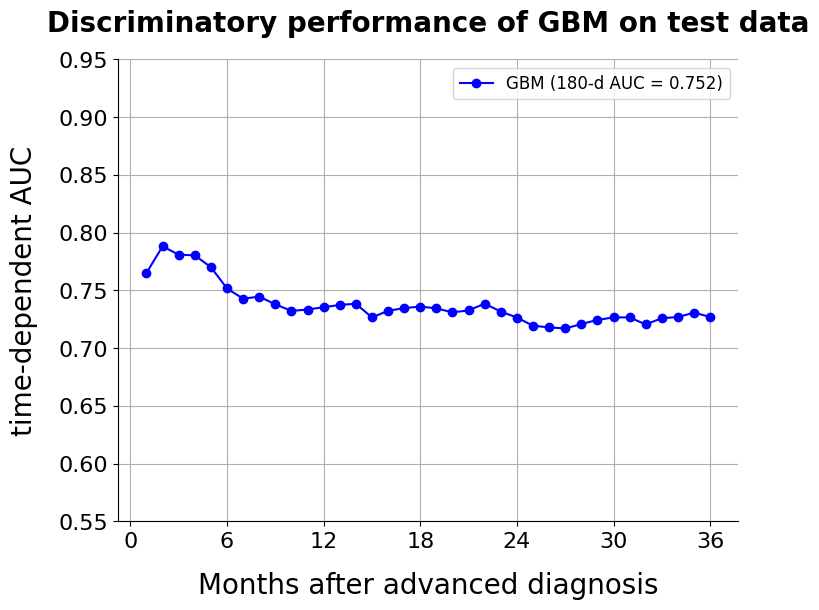

In [37]:
fig, ax0 = plt.subplots(figsize=(8, 6))

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

ax0.plot(times/30, 
         gbm_auc_over5_df.loc['gbm'].values[0:36], 
         'o-', 
         color = 'blue', 
         label = f"GBM (180-d AUC = {final_auc_test:.3f})")

ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.55, 1.0, 0.05))
ax0.tick_params(axis = 'both', which = 'major', labelsize = 16) 

ax0.set_title('Discriminatory performance of GBM on test data', weight = 'bold', size = 20, pad = 20)
ax0.set_xlabel('Months after advanced diagnosis', labelpad = 15, size = 20)
ax0.set_ylabel('time-dependent AUC', labelpad = 15, size = 20)
ax0.legend(loc = 'upper right', prop = {'size': 12})
ax0.grid(True)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

plt.show()

Total number of features: 115
Number of non-zero features in final model: 76


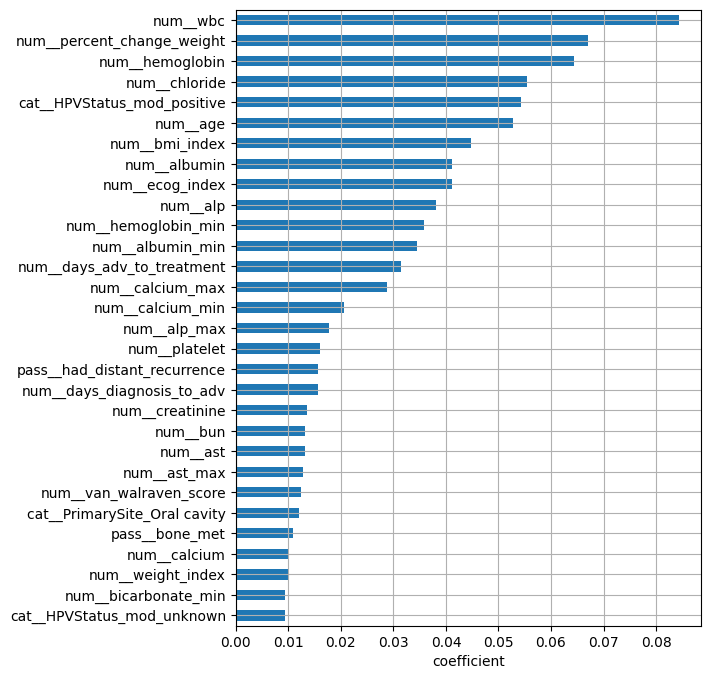

In [38]:
# Dataframe of coefficients for each variable 
gbm_feature_importance = pd.DataFrame(
    full_pipeline_final.named_steps['model'].feature_importances_,
    index = full_pipeline_final.named_steps['preprocessor'].get_feature_names_out(),
    columns = ['coefficient']
)

print('Total number of features: {}'.format(len(all_var)))

non_zero = np.sum(gbm_feature_importance.iloc[:, 0] != 0)
print('Number of non-zero features in final model: {}'.format(non_zero))

non_zero_coefs = gbm_feature_importance.query('coefficient != 0')
coef_order = non_zero_coefs.abs().sort_values('coefficient').tail(30).index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax = ax, legend = False)
ax.set_xlabel('coefficient')
ax.grid(True)

In [39]:
gbm_feature_importance = (
    gbm_feature_importance
    .reset_index()
    .rename(columns = {'index':'variable'})
)

In [40]:
gbm_feature_importance.to_csv('../outputs/gbm_feature_importance.csv', index = False, header = True)

## Calculating risk scores and probability survival
**Risk scores are calculated for each patient using 3-fold cross-validation. For each fold, a model is trained on 67% of the data, and risk scores are generated for patients in the held-out 33%. This approach ensures that each patient's risk score and probability survival is based on a model that does not include them in training, providing unbiased predictions.**

### Preprocessing

In [41]:
df = pd.concat([train_df, test_df])

In [42]:
df.shape

(8718, 191)

In [43]:
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [44]:
model_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 2,
    'subsample': 0.75,
    'max_features': 0.9,
    'verbose': 1,
    'random_state': 42
}

cv_scores_df = cross_validated_survival_predictions(
    df = df,                      
    y = y,                      
    all_var = all_var,                 
    preprocessor = preprocessor,            
    model_params = model_params,            
    survival_timepoints = (180, 365),     
    tau = 365,                     
    n_splits = 5,              
    random_state = 42,         
    verbose = True  
)

Processing fold 1/5
      Iter       Train Loss      OOB Improve   Remaining Time 
         1       28587.7509           3.4259            4.21m
         2       28728.0732         133.1037            4.17m
         3       28768.7569          50.5270            4.16m
         4       28420.1640        -290.3538            4.16m
         5       28640.2819         201.1869            4.15m
         6       28587.6517         -32.3276            4.14m
         7       28578.3389           1.3154            4.13m
         8       28588.6793          14.8063            4.12m
         9       28608.6312          33.7390            4.11m
        10       28568.1252         -25.4684            4.10m
        20       28455.7920          49.7236            4.01m
        30       28373.0976         -25.4782            3.92m
        40       28188.2150         -57.7123            3.83m
        50       28239.2885        -161.5952            3.74m
        60       28168.1884        -123.1965     

In [45]:
cv_scores_df.to_csv('../outputs/gb_survival_predictions.csv')